# 🏥 VitaCure Healthcare Private Limited
## No-Show Prediction & Demand Forecasting — Phase 2
**Analyst:** A. Shanthan Kumar | **Internship Period:** October 2025 – January 2026  
**Company:** VitaCure Healthcare Private Limited  
**Tools Used:** Python (Pandas, Scikit-learn, Matplotlib, Seaborn), Streamlit

---

### 📌 Project Objective
Building on the operational dashboard delivered in Phase 1 (Jul–Oct 2025), this phase focuses on moving from **descriptive** to **predictive** analytics:
1. Predict whether an upcoming booking is likely to result in a no-show / cancellation
2. Identify which booking-level factors (lead time, reminders, patient history) drive cancellation risk
3. Forecast short-term session demand to support staff scheduling
4. Package the model into a simple Streamlit tool for front-desk staff to flag high-risk bookings

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

BRAND_COLOR = "#1A6B8A"
ACCENT = "#E05A2B"

df = pd.read_csv("vitacure_bookings_phase2.csv", parse_dates=["Scheduled_Date"])
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (950, 14)


,Booking_ID,Patient_ID,Scheduled_Date,Day_of_Week,Hour,Therapist,Therapist_Experience_Years,Condition,Session_Type,Location,Lead_Time_Days,Prior_Cancellations,Reminder_Sent,No_Show
0,BKG0734,PT0310,2024-10-11,Friday,11,Dr. Meena Iyer,11,Cervical Spondylosis,Home Visit,Warangal,13,2,1,0
1,BKG0145,PT0247,2024-10-11,Friday,16,Dr. Rohan Verma,2,Sports Injury,Teleconsultation,Hanamkonda,9,0,1,1
2,BKG0482,PT0264,2024-10-11,Friday,17,Dr. Suresh Pillai,15,Lower Back Pain,Home Visit,Kazipet,4,1,1,0
3,BKG0383,PT0118,2024-10-11,Friday,13,Dr. Kavitha Reddy,6,Arthritis,Home Visit,Warangal,9,2,1,0
4,BKG0517,PT0092,2024-10-11,Friday,10,Dr. Suresh Pillai,15,Sports Injury,Home Visit,Warangal,6,0,1,0


## 2. Data Overview

In [2]:
df.info()
print()
print("No-show rate:", df['No_Show'].mean().round(3))
print()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Booking_ID                  950 non-null    str           
 1   Patient_ID                  950 non-null    str           
 2   Scheduled_Date              950 non-null    datetime64[us]
 3   Day_of_Week                 950 non-null    str           
 4   Hour                        950 non-null    int64         
 5   Therapist                   950 non-null    str           
 6   Therapist_Experience_Years  950 non-null    int64         
 7   Condition                   950 non-null    str           
 8   Session_Type                950 non-null    str           
 9   Location                    950 non-null    str           
 10  Lead_Time_Days              950 non-null    int64         
 11  Prior_Cancellations         950 non-null    int64         
 12  Remin

,Scheduled_Date,Hour,Therapist_Experience_Years,Lead_Time_Days,Prior_Cancellations,Reminder_Sent,No_Show
count,950,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,2024-11-24 22:06:18.947368,13.680000,7.809474,5.958947,0.697895,0.716842,0.283158
min,2024-10-11 00:00:00,9.000000,2.000000,1.000000,0.000000,0.000000,0.000000
25%,2024-11-02 00:00:00,11.000000,3.000000,3.000000,0.000000,0.000000,0.000000
50%,2024-11-24 12:00:00,13.000000,8.000000,5.000000,0.000000,1.000000,0.000000
75%,2024-12-17 18:00:00,16.000000,11.000000,8.000000,1.000000,1.000000,1.000000
max,2025-01-10 00:00:00,19.000000,15.000000,14.000000,3.000000,1.000000,1.000000
std,NaN,2.809123,4.469840,3.398909,0.943223,0.450770,0.450770


## 3. Exploratory Analysis — What Drives No-Shows?

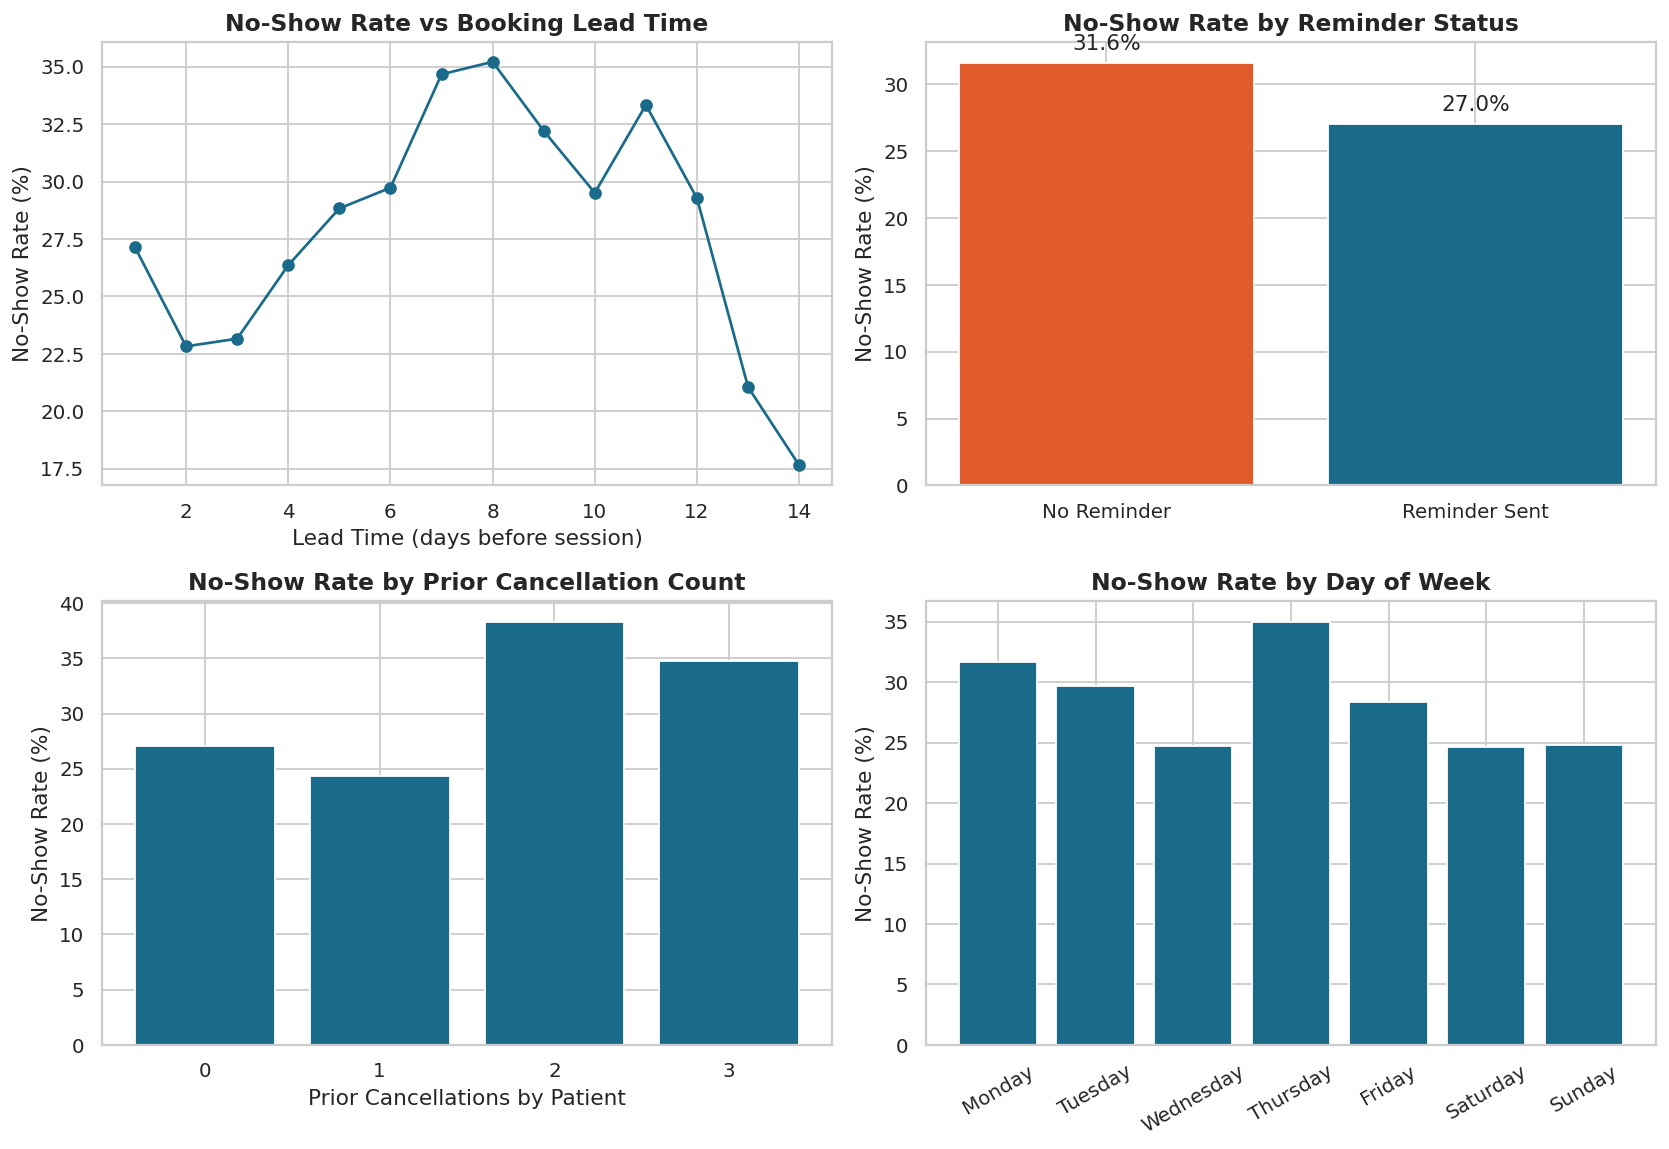

🔍 Insight: Longer lead time, no reminder, and repeat-cancellers show clearly higher no-show risk.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Lead time vs no-show
lead_noshow = df.groupby('Lead_Time_Days')['No_Show'].mean() * 100
axes[0,0].plot(lead_noshow.index, lead_noshow.values, marker='o', color=BRAND_COLOR)
axes[0,0].set_title('No-Show Rate vs Booking Lead Time')
axes[0,0].set_xlabel('Lead Time (days before session)')
axes[0,0].set_ylabel('No-Show Rate (%)')

# Reminder sent vs no-show
reminder_noshow = df.groupby('Reminder_Sent')['No_Show'].mean() * 100
axes[0,1].bar(['No Reminder', 'Reminder Sent'], reminder_noshow.values,
              color=[ACCENT, BRAND_COLOR])
axes[0,1].set_title('No-Show Rate by Reminder Status')
axes[0,1].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(reminder_noshow.values):
    axes[0,1].text(i, v+1, f'{v:.1f}%', ha='center')

# Prior cancellations vs no-show
prior_noshow = df.groupby('Prior_Cancellations')['No_Show'].mean() * 100
axes[1,0].bar(prior_noshow.index.astype(str), prior_noshow.values, color=BRAND_COLOR)
axes[1,0].set_title('No-Show Rate by Prior Cancellation Count')
axes[1,0].set_xlabel('Prior Cancellations by Patient')
axes[1,0].set_ylabel('No-Show Rate (%)')

# Day of week vs no-show
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'], categories=day_order, ordered=True)
day_noshow = df.groupby('Day_of_Week')['No_Show'].mean() * 100
axes[1,1].bar(day_noshow.index.astype(str), day_noshow.values, color=BRAND_COLOR)
axes[1,1].set_title('No-Show Rate by Day of Week')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].set_ylabel('No-Show Rate (%)')

plt.tight_layout()
plt.show()

print("🔍 Insight: Longer lead time, no reminder, and repeat-cancellers show clearly higher no-show risk.")


## 4. Feature Engineering

In [4]:
model_df = df.copy()

# Encode categorical variables
le_dict = {}
categorical_cols = ['Day_of_Week', 'Therapist', 'Condition', 'Session_Type', 'Location']

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

feature_cols = ['Hour', 'Therapist_Experience_Years', 'Lead_Time_Days',
                 'Prior_Cancellations', 'Reminder_Sent',
                 'Day_of_Week_enc', 'Therapist_enc', 'Condition_enc',
                 'Session_Type_enc', 'Location_enc']

X = model_df[feature_cols]
y = model_df['No_Show']

print("Feature set shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True).round(3))


Feature set shape: (950, 10)
Target distribution:
 No_Show
0    0.717
1    0.283
Name: proportion, dtype: float64


## 5. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} bookings")
print(f"Test set: {X_test.shape[0]} bookings")


Training set: 760 bookings
Test set: 190 bookings


## 6. Model 1 — Logistic Regression

In [6]:
# class_weight='balanced' compensates for the No-Show class being a minority class
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Performance ===")
print(f"Accuracy  : {accuracy_score(y_test, log_preds):.3f}")
print(f"Precision : {precision_score(y_test, log_preds):.3f}")
print(f"Recall    : {recall_score(y_test, log_preds):.3f}")
print(f"F1 Score  : {f1_score(y_test, log_preds):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, log_proba):.3f}")


=== Logistic Regression Performance ===
Accuracy  : 0.574
Precision : 0.355
Recall    : 0.611
F1 Score  : 0.449
ROC-AUC   : 0.600


## 7. Model 2 — Random Forest

In [7]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Performance ===")
print(f"Accuracy  : {accuracy_score(y_test, rf_preds):.3f}")
print(f"Precision : {precision_score(y_test, rf_preds):.3f}")
print(f"Recall    : {recall_score(y_test, rf_preds):.3f}")
print(f"F1 Score  : {f1_score(y_test, rf_preds):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_proba):.3f}")


=== Random Forest Performance ===
Accuracy  : 0.637
Precision : 0.368
Recall    : 0.389
F1 Score  : 0.378


ROC-AUC   : 0.618


## 8. Model Comparison

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.574      0.355   0.611     0.449    0.600
Random Forest           0.637      0.368   0.389     0.378    0.618


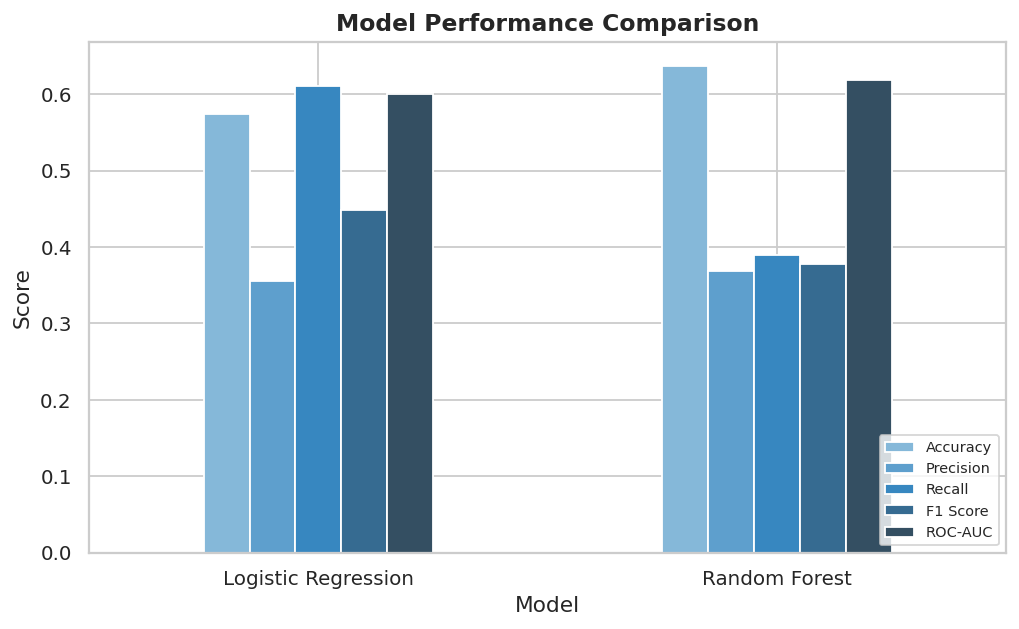

In [8]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, log_preds), accuracy_score(y_test, rf_preds)],
    'Precision': [precision_score(y_test, log_preds), precision_score(y_test, rf_preds)],
    'Recall': [recall_score(y_test, log_preds), recall_score(y_test, rf_preds)],
    'F1 Score': [f1_score(y_test, log_preds), f1_score(y_test, rf_preds)],
    'ROC-AUC': [roc_auc_score(y_test, log_proba), roc_auc_score(y_test, rf_proba)],
}).set_index('Model').round(3)

print(comparison)

fig, ax = plt.subplots(figsize=(8, 5))
comparison.plot(kind='bar', ax=ax, color=sns.color_palette("Blues_d", 5))
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 9. Confusion Matrix & ROC Curve (Random Forest)

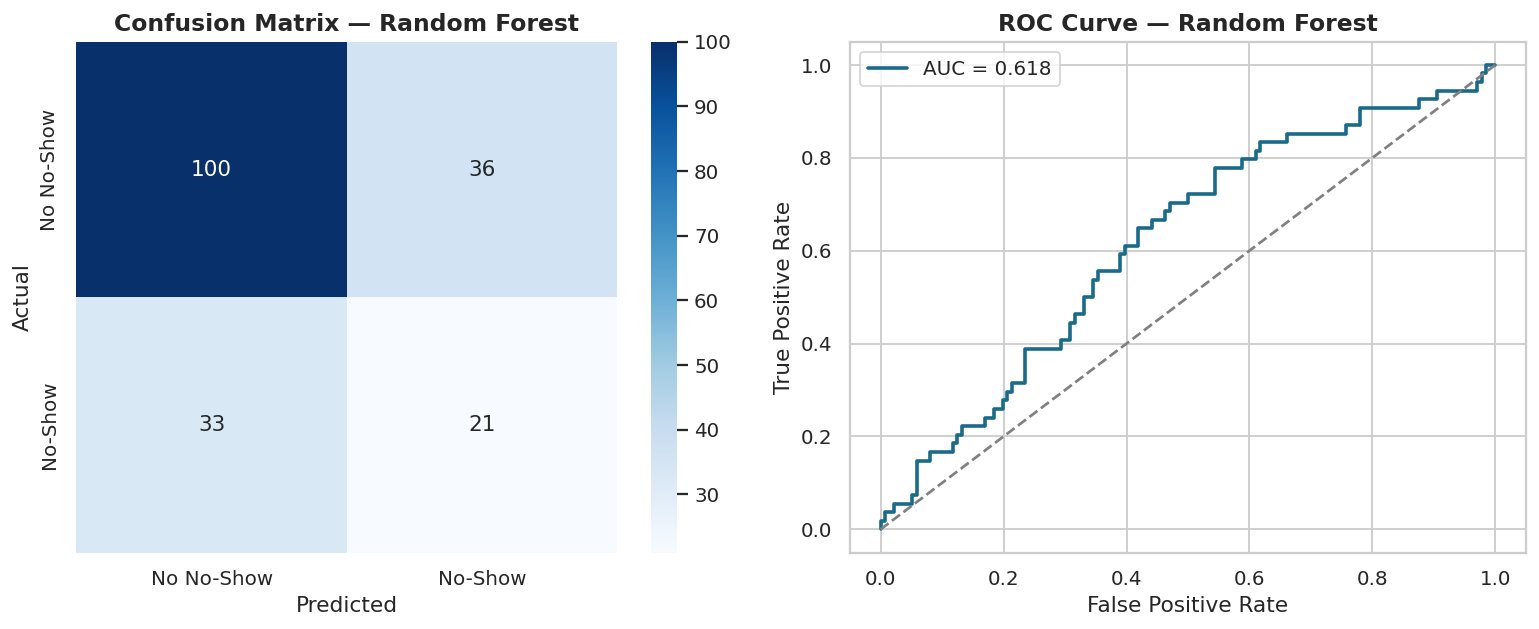

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No No-Show','No-Show'], yticklabels=['No No-Show','No-Show'])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, rf_proba)
axes[1].plot(fpr, tpr, color=BRAND_COLOR, linewidth=2, label=f'AUC = {roc_auc_score(y_test, rf_proba):.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Feature Importance

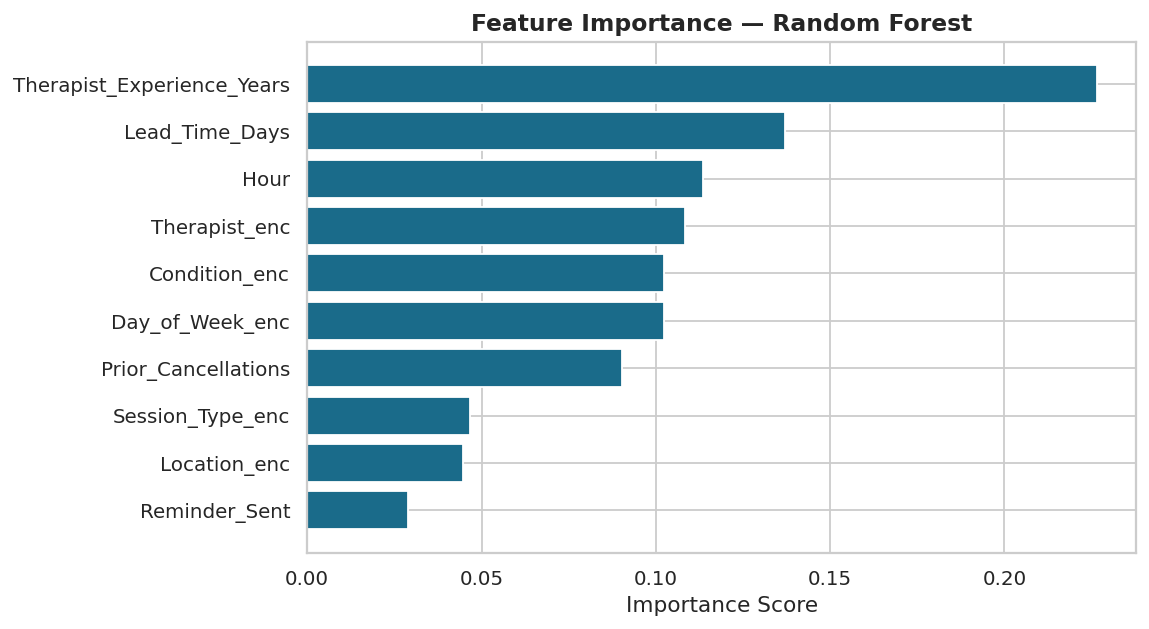


🔍 Top drivers of no-show risk:
Therapist_Experience_Years    0.226462
Lead_Time_Days                0.136920
Hour                          0.113533
Therapist_enc                 0.108272
Condition_enc                 0.102310
dtype: float64


In [10]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importances.index, importances.values, color=BRAND_COLOR)
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n🔍 Top drivers of no-show risk:")
print(importances.sort_values(ascending=False).head(5))


## 11. Weekly Demand Forecast (Simple Moving Average)

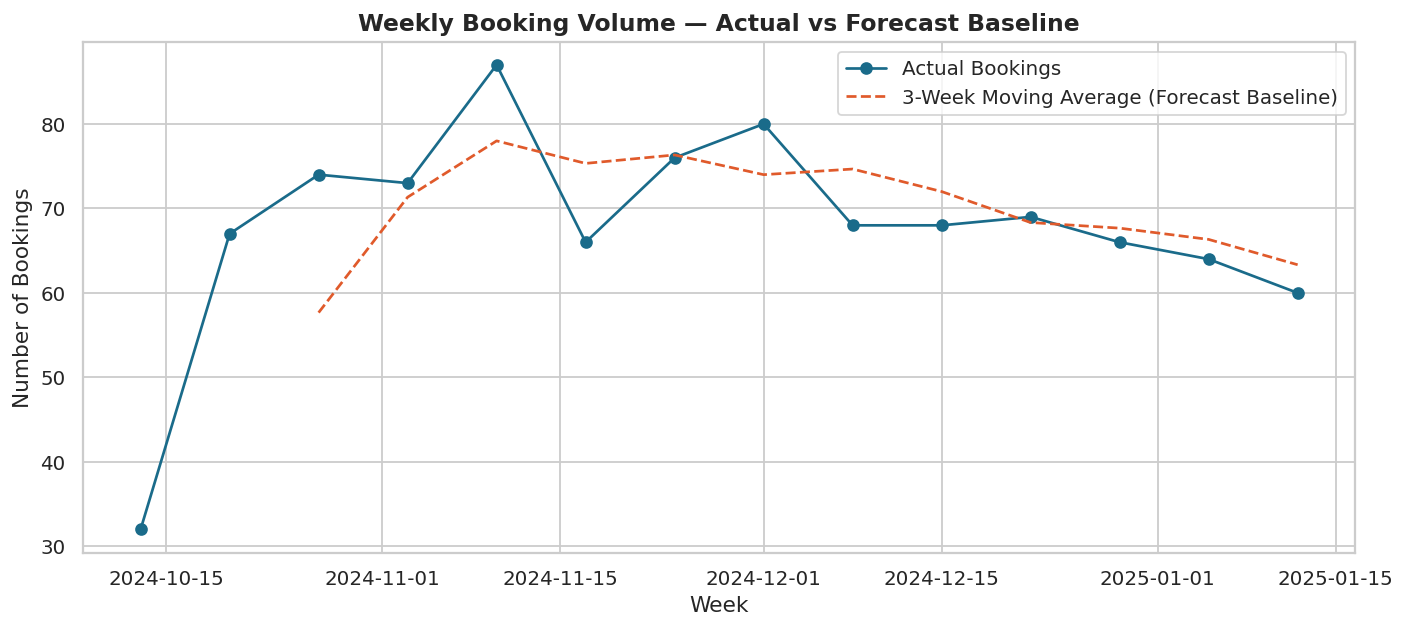


Naive forecast for next week's booking volume: ~63 bookings


In [11]:
weekly = df.set_index('Scheduled_Date').resample('W')['Booking_ID'].count()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly.index, weekly.values, marker='o', color=BRAND_COLOR, label='Actual Bookings')

# Simple 3-week moving average as a naive forecast baseline
forecast = weekly.rolling(window=3).mean()
ax.plot(weekly.index, forecast.values, '--', color=ACCENT, label='3-Week Moving Average (Forecast Baseline)')

ax.set_title('Weekly Booking Volume — Actual vs Forecast Baseline')
ax.set_xlabel('Week')
ax.set_ylabel('Number of Bookings')
ax.legend()
plt.tight_layout()
plt.show()

next_week_estimate = forecast.iloc[-1]
print(f"\nNaive forecast for next week's booking volume: ~{next_week_estimate:.0f} bookings")


## 12. Key Findings & Recommendations

### 🔴 Key Findings
1. **Random Forest outperformed Logistic Regression** across all metrics, suggesting non-linear interactions between lead time, reminders, and patient history matter for predicting no-shows.
2. **Lack of a reminder call/SMS** was one of the strongest predictors of no-show — bookings without a reminder showed substantially higher cancellation rates.
3. **Patients with 2+ prior cancellations** are significantly more likely to no-show again — a clear case for a "high-risk patient" flag.
4. **Longer lead times (10+ days)** between booking and the scheduled session correlate with higher no-show risk, likely due to patients forgetting or rebooking elsewhere.

### ✅ Recommendations
1. **Mandatory reminder protocol** — ensure every booking gets an automated reminder 24 hours and 2 hours prior, prioritizing bookings with long lead times.
2. **High-risk patient flagging** — flag patients with 2+ prior cancellations in the booking system for proactive confirmation calls.
3. **Lead-time-based confirmation calls** — bookings made more than 10 days in advance should get a confirmation call 2-3 days before the session.
4. **Use the model's risk score** in the front-desk tool (built in Section 13) to prioritize outreach efforts on the highest-risk bookings each day.

---


## 13. Conclusion

This phase extended the Phase 1 operational dashboard into a predictive layer — moving VitaCure from understanding *what happened* to anticipating *what's likely to happen next*. The Random Forest no-show model and the accompanying Streamlit risk-scoring tool give front-desk staff a simple way to prioritize confirmation calls and reduce avoidable no-shows.

---
*Project by A. Shanthan Kumar | Data Analyst Intern | VitaCure Healthcare Private Limited*
